# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [171]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('Rainfall.csv')

# Displauy first 5 row
print(df.head())

# Handle missing value
missing_values = df.isnull().sum()
print("Missing values:", missing_values)

# summary
summary_stats = df.describe()
print(summary_stats)


  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
0  North  2023   Jan  StationA         56.2          9       12.1        2.5   
1  North  2023   Feb  StationA         72.1         12       14.7        3.0   
2  North  2023   Jan  StationB         60.5         10       11.2        1.8   
3  South  2023   Jan  StationC         81.0         13       19.6        7.2   
4  South  2023   Feb  StationC         63.4         11       20.1        7.7   

  UrbanRural  
0      Urban  
1      Urban  
2      Rural  
3      Urban  
4      Urban  
Missing values: Region         0
Year           0
Month          0
Station        0
Rainfall_mm    0
RainyDays      0
MaxTemp_C      0
MinTemp_C      0
UrbanRural     0
dtype: int64
         Year  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
count    10.0    10.000000   10.00000  10.000000  10.000000
mean   2023.0    66.160000   10.90000  16.100000   4.740000
std       0.0    12.154121    1.66333   2.982542   2.029888
min    

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [173]:
station = df.groupby('Station').agg({
    'Rainfall_mm': 'sum',
    'RainyDays': 'mean',
    'MaxTemp_C': 'mean',
    'MinTemp_C': 'mean'
}).reset_index()

print(station)

    Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C
0  StationA        128.3       10.5      13.40       2.75
1  StationB        122.0       10.5      13.10       2.50
2  StationC        144.4       12.0      19.85       7.45
3  StationD        105.3        9.0      16.65       5.90
4  StationE        161.6       12.5      17.50       5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [174]:
region_urban = df.groupby(['Region', 'UrbanRural']).agg({
    'Rainfall_mm': 'mean',
    'MaxTemp_C': 'mean',
    'RainyDays': 'mean'
}).reset_index()

print(region_urban)

  Region UrbanRural  Rainfall_mm  MaxTemp_C  RainyDays
0   East      Rural        52.65      16.65        9.0
1  North      Rural        61.00      13.10       10.5
2  North      Urban        64.15      13.40       10.5
3  South      Urban        72.20      19.85       12.0
4   West      Urban        80.80      17.50       12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [175]:
month_region = df.groupby(['Month', 'Region']).agg({
    'Rainfall_mm': ['sum', 'mean', 'min', 'max']
}).reset_index()

print(month_region)


  Month Region Rainfall_mm                   
                       sum   mean   min   max
0   Feb   East        59.6  59.60  59.6  59.6
1   Feb  North        72.1  72.10  72.1  72.1
2   Feb  South        63.4  63.40  63.4  63.4
3   Feb   West        84.2  84.20  84.2  84.2
4   Jan   East        45.7  45.70  45.7  45.7
5   Jan  North       116.7  58.35  56.2  60.5
6   Jan  South        81.0  81.00  81.0  81.0
7   Jan   West        77.4  77.40  77.4  77.4
8   Mar  North        61.5  61.50  61.5  61.5


4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [176]:
highest_rainfall = df.loc[df['Rainfall_mm'].idxmax()]

print(highest_rainfall[['Region', 'Month', 'Rainfall_mm']])

Region         West
Month           Feb
Rainfall_mm    84.2
Name: 8, dtype: object


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [177]:
year_urban = df.groupby(['Year', 'UrbanRural']).agg({
    'Rainfall_mm': ['mean', 'min', 'max']
}).reset_index()

print(year_urban)

   Year UrbanRural Rainfall_mm            
                          mean   min   max
0  2023      Rural   56.825000  45.7  61.5
1  2023      Urban   72.383333  56.2  84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [178]:
df['Temp_Range'] = df['MaxTemp_C'] - df['MinTemp_C'] 

temp_range = df.groupby('Region')['Temp_Range'].mean().reset_index()

print(temp_range)


  Region  Temp_Range
0   East      10.750
1  North      10.625
2  South      12.400
3   West      12.400


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



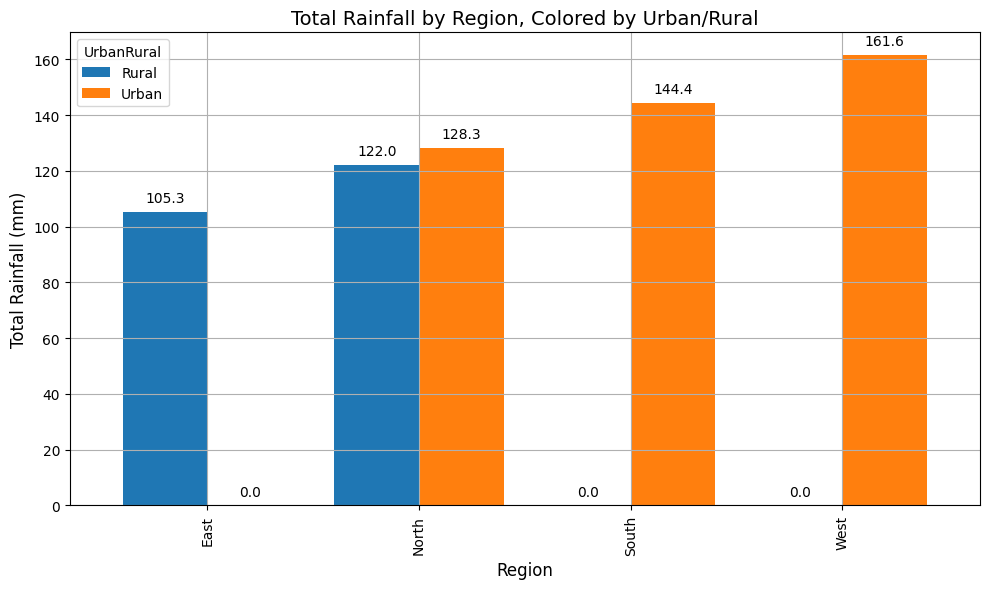

In [179]:
import matplotlib.pyplot as plt

# Group data
rainfall_by_region = df.groupby(['Region', 'UrbanRural'])['Rainfall_mm'].sum().unstack()
rainfall_by_region.plot(kind='bar', figsize=(10, 6), width=0.8)

# Plot chart
plt.title('Total Rainfall by Region, Colored by Urban/Rural', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.grid(True)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       xytext=(0, 5), 
                       textcoords='offset points', 
                       ha='center', va='bottom')

plt.tight_layout()
plt.savefig("barchart_total_rainfall_by_region.png")
plt.show()


2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



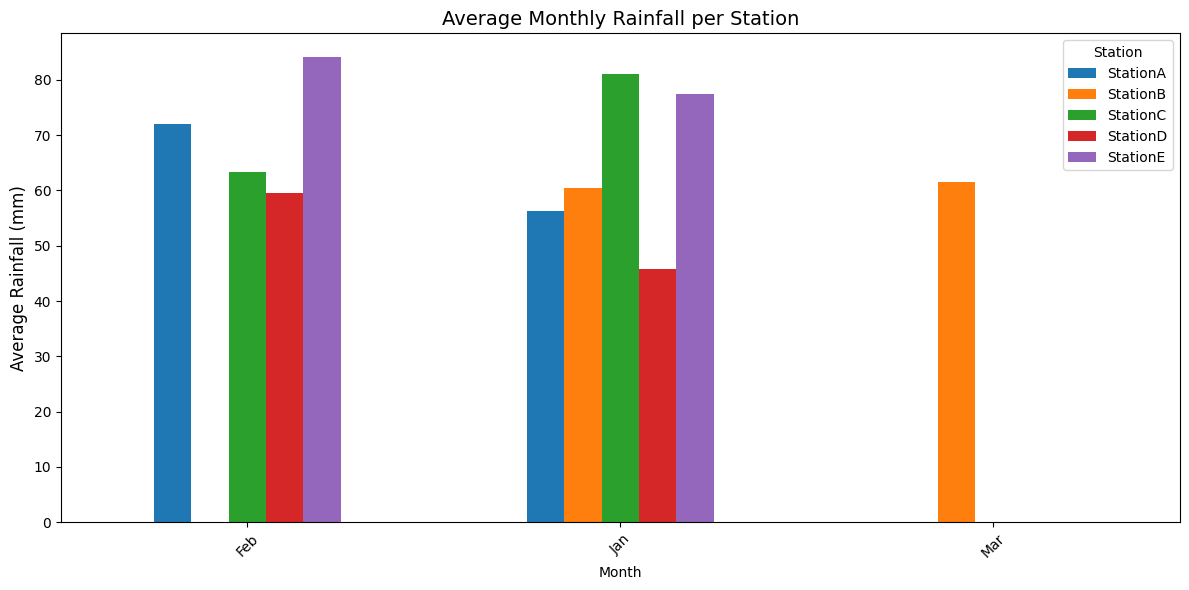

In [180]:
#Write your code here
monthly_rainfall = df.groupby(["Month", "Station"])["Rainfall_mm"].mean().unstack()

monthly_rainfall.plot(kind="bar", figsize=(12, 6))
plt.title("Average Monthly Rainfall per Station", fontsize=14)
plt.ylabel("Average Rainfall (mm)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Station")
plt.tight_layout()
plt.savefig("barchart_mean_rainfall_per_station.png")
plt.show()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



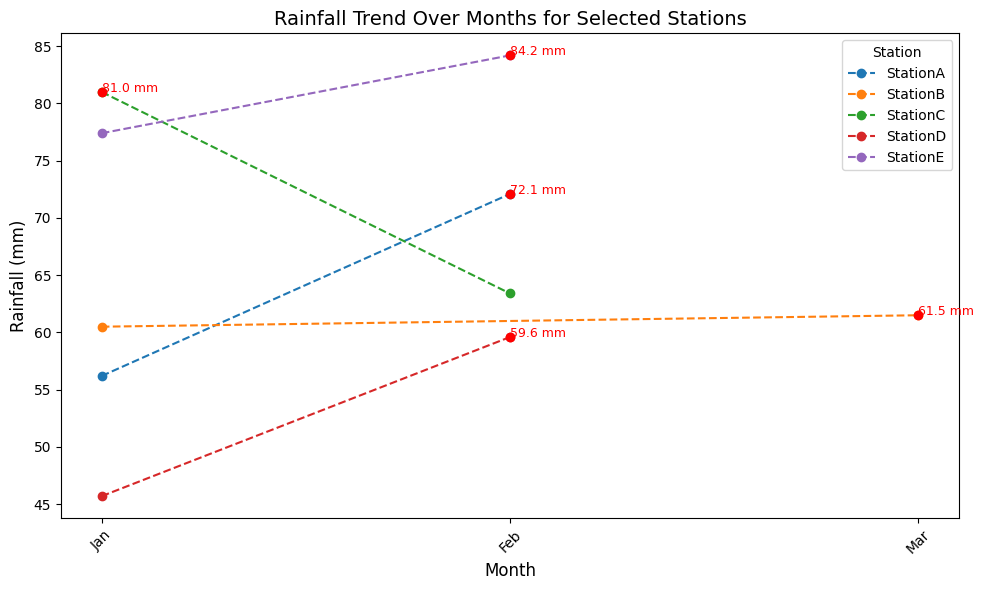

In [181]:
# Month
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Station
stations = ['StationA', 'StationB', 'StationC', 'StationD', 'StationE']

# Plot
plt.figure(figsize=(10, 6))

for station in stations:
    station_data = df[df['Station'] == station]
    plt.plot(station_data['Month'], station_data['Rainfall_mm'], marker='o', linestyle='--', label=station)
    max_rainfall_month = station_data.loc[station_data['Rainfall_mm'].idxmax()]
    plt.scatter(max_rainfall_month['Month'], max_rainfall_month['Rainfall_mm'], color='red', zorder=5)
    plt.text(max_rainfall_month['Month'], max_rainfall_month['Rainfall_mm'], 
             f'{max_rainfall_month["Rainfall_mm"]} mm', color='red', fontsize=9, ha='left')

# Add detail
plt.title('Rainfall Trend Over Months for Selected Stations', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.legend(title='Station')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lineplot_monthly_rainfall_trend_by_stations.png")
plt.show()


4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



<Figure size 1000x600 with 0 Axes>

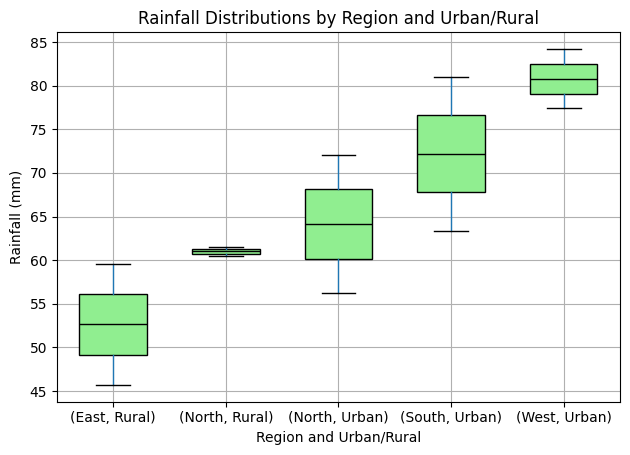

In [182]:
# Create the boxplot
plt.figure(figsize=(10, 6))
df.boxplot(column='Rainfall_mm', by=['Region', 'UrbanRural'], grid=True, patch_artist=True, 
           medianprops=dict(color='black'), widths=0.6, 
           boxprops=dict(facecolor='lightgreen', color='black')) 

# Add detail
plt.title('Rainfall Distributions by Region and Urban/Rural')
plt.suptitle('')  # To remove the default title generated by pandas
plt.xlabel('Region and Urban/Rural')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.savefig("boxplot_rainfall_by_urbanrural.png")
plt.show()


5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



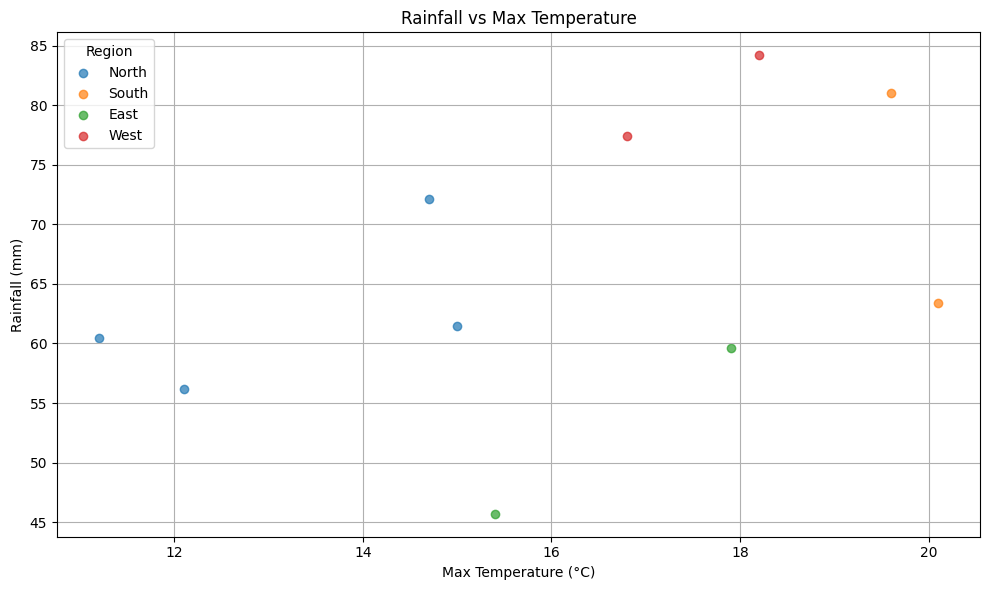

In [183]:
# Create scatter plot
plt.figure(figsize=(10, 6))
for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    plt.scatter(region_data['MaxTemp_C'], region_data['Rainfall_mm'], label=region, alpha=0.7)

# Add detail
plt.title('Rainfall vs Max Temperature')
plt.xlabel('Max Temperature (°C)')
plt.ylabel('Rainfall (mm)')
plt.grid(True)
plt.legend(title='Region')
plt.tight_layout()
plt.savefig("scatter_rainfall_maxtemp_region.png")
plt.show()


6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



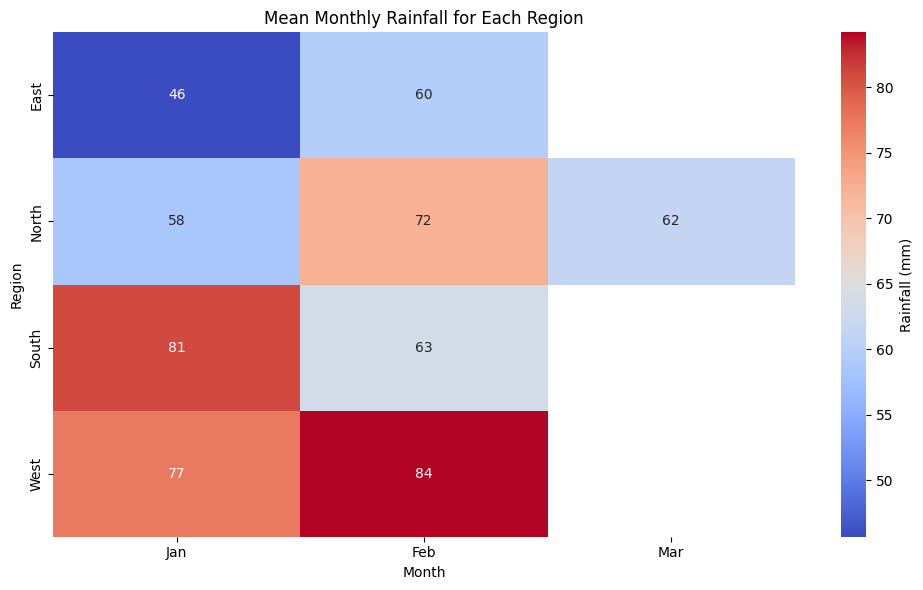

In [184]:
# Create pivot table 
rainfall_pivot = df.pivot_table(values='Rainfall_mm', index='Region', columns='Month', aggfunc='mean', observed=False)

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(rainfall_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'Rainfall (mm)'})

# Add detail
plt.title('Mean Monthly Rainfall for Each Region')
plt.xlabel('Month')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig("heatmap_mean_rainfall_by_region.png")
plt.show()


7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [118]:
#Write your code here



## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


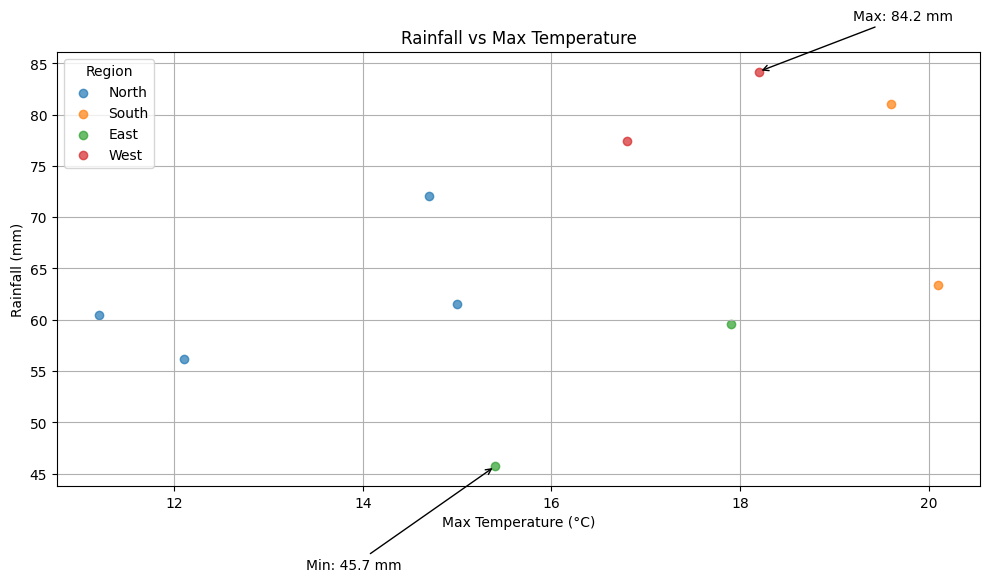

In [186]:
# Create scatter plot
plt.figure(figsize=(10, 6))
for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    plt.scatter(region_data['MaxTemp_C'], region_data['Rainfall_mm'], label=region, alpha=0.7)
    
# Annotate the highest point
plt.annotate(f"Max: {max_rainfall['Rainfall_mm']} mm", 
             xy=(max_rainfall['MaxTemp_C'], max_rainfall['Rainfall_mm']), 
             xytext=(max_rainfall['MaxTemp_C'] + 1, max_rainfall['Rainfall_mm'] + 5),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

# Annotate the lowest point
plt.annotate(f"Min: {min_rainfall['Rainfall_mm']} mm", 
             xy=(min_rainfall['MaxTemp_C'], min_rainfall['Rainfall_mm']), 
             xytext=(min_rainfall['MaxTemp_C'] - 2, min_rainfall['Rainfall_mm'] - 10),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

# Add detail
plt.title('Rainfall vs Max Temperature')
plt.xlabel('Max Temperature (°C)')
plt.ylabel('Rainfall (mm)')
plt.grid(True)
plt.legend(title='Region')
plt.tight_layout()
plt.savefig("scatter_rainfall_maxtemp_region.png")
plt.show()


2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


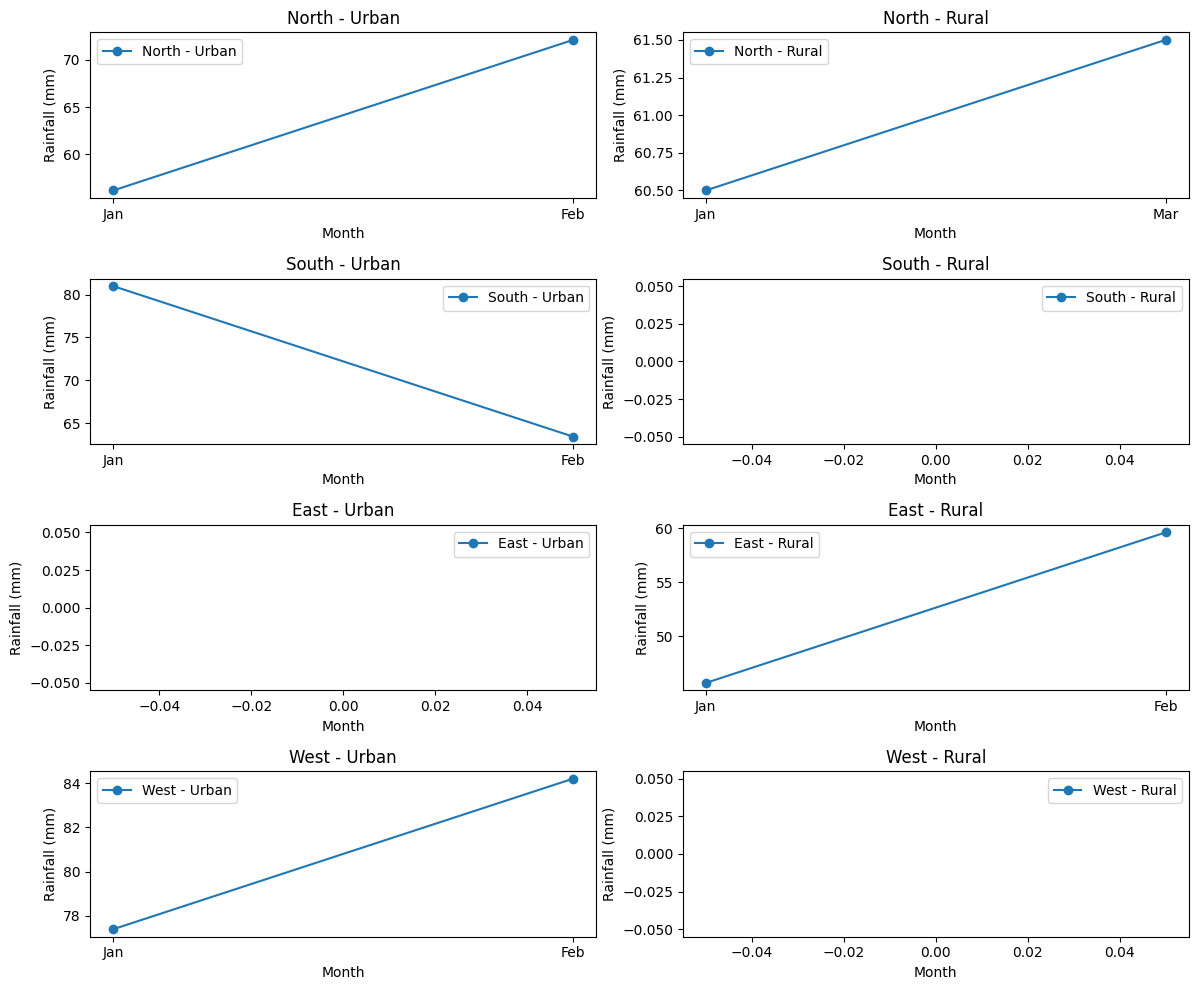

In [189]:
regions = df['Region'].unique()
urban_rural = df['UrbanRural'].unique()

nrows = len(regions)
ncols = len(urban_rural)

# Create facet/grid plot
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 10))

for i, region in enumerate(regions):
    for j, status in enumerate(urban_rural):
        ax = axes[i, j]  # Select the subplot
        filtered_data = df[(df['Region'] == region) & (df['UrbanRural'] == status)]
        
        # Plot the rainfall trend for this combination
        ax.plot(filtered_data['Month'], filtered_data['Rainfall_mm'], marker='o', label=f'{region} - {status}')
        
        # Add details
        ax.set_title(f'{region} - {status}')
        ax.set_xlabel('Month')
        ax.set_ylabel('Rainfall (mm)')
        ax.legend()

plt.tight_layout()
plt.savefig('facet_grid_rainfall_trends.png')
plt.show()


3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)

The analysis of rainfall data reveals distinct trends across regions and Urban/Rural areas. Urban areas tend to have more consistent rainfall, while rural areas experience greater variability. The Southern region receives significantly more rainfall than the Northern region. Outliers in rainfall indicate extreme weather events, which are important for planning in agriculture and infrastructure. The comparison of rainfall trends across regions and environments highlights the impact of urbanization on local weather patterns.